In [21]:
%load_ext autoreload
%autoreload 2

from IPython.core.debugger import set_trace
from config import parse_args
args = parse_args("",None)

import sys
#sys.path.insert(0, args.worktree)
#sys.path.insert(0,  "/home/kim2712/Desktop/research/BGAN/BGAN")
sys.path.insert(0, "/Users/kjungeum/PycharmProjects/BGAN/BGAN")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch

if torch.backends.mps.is_available():
    args.device = "mps"

args.epoch = 5
#args.n_steps = 20

In [31]:
#from BGAN_deep_critic import DBGAN_mix as BGAN
#from BGAN_double_deep_critic import double_DBGAN as BGAN
from BGAN import BGAN
from _data.lotka_voltera import simulate as forward_sampler
from _data.lotka_voltera import integrate
from os.path import join
import pathlib

In [32]:
def simulator(batch_size, np_random=None, device = args.device, n_steps = args.n_steps):
        Thetas, x = forward_sampler(batch_size,np_random=np_random, n_steps = n_steps)
        Thetas = torch.from_numpy(Thetas).float().to(device)
        X = torch.from_numpy(x).float().to(device)
        X = X.clip(0,10**7)
        X = X.permute(0, 3, 2,1).squeeze(-1)
        return Thetas, X


In [33]:
import numpy as np
import torch

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

method = BGAN(simulator=simulator,
             epoch=args.epoch,
              x_length = args.n_steps+1,
             x_dim = 2,
             theta_dim=4,
              z_dim=4,
              device=args.device
              )
#factor: 16, 32, 64, 128
#f1_layers: 0,1,2
#common_layers: 2,3
#hidden_layers: 0,1,2
#d_hidden: 16, 32, 64, 128
#common_factor: 16 32 64 128
#print(method.generator, method.critic)
#

In [34]:
Theta0 = [1,0.01,0.5,0.01]
X0 = integrate(a0 = [1],
             b0 = [0.01],
             c0 = [0.5],
             d0 = [0.01],
             x0=100, y0=50,
             timestep=0.1, np_random=None, seed=1234, u_up=1.2, u_down=0.8, n_steps=args.n_steps)
X0 = X0.transpose(0, 2, 1)  # Rearrange the dimensions

X0_rep = torch.from_numpy(np.repeat(X0, repeats=150, axis=0)).float().to(args.device)
true_thetas = np.repeat([Theta0], repeats=150, axis=0)

In [35]:
def plot(self, save_path=None, show=True):
    n_row, n_col = 2, 4
    fig, axis = plt.subplots(n_row, n_col, figsize=(4 * n_col, 4 * n_row))#, sharex=True, sharey=True)
    # set_trace()
    with torch.no_grad():
        sample = self.generator(X0_rep.to(args.device)).to("cpu").detach().numpy()
    # sample += torch.randn(size=sample.shape)*0.00001
    for i in range(4):
        ax = axis[0,i]
        sns.kdeplot(x=sample[:, i], ax=ax, fill=True, color="blue")
        ax.axvline(x=Theta0[i], color='red', linestyle='--', linewidth=2)

    pd.DataFrame(self.qualities).plot(y="mse", ax=axis[1,0])
    pd.DataFrame(self.qualities).plot(y="loss", ax=axis[1,1])
    if show:
        plt.show()
    else:
        plt.savefig(save_path)  # Save the plot to the specified path

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5


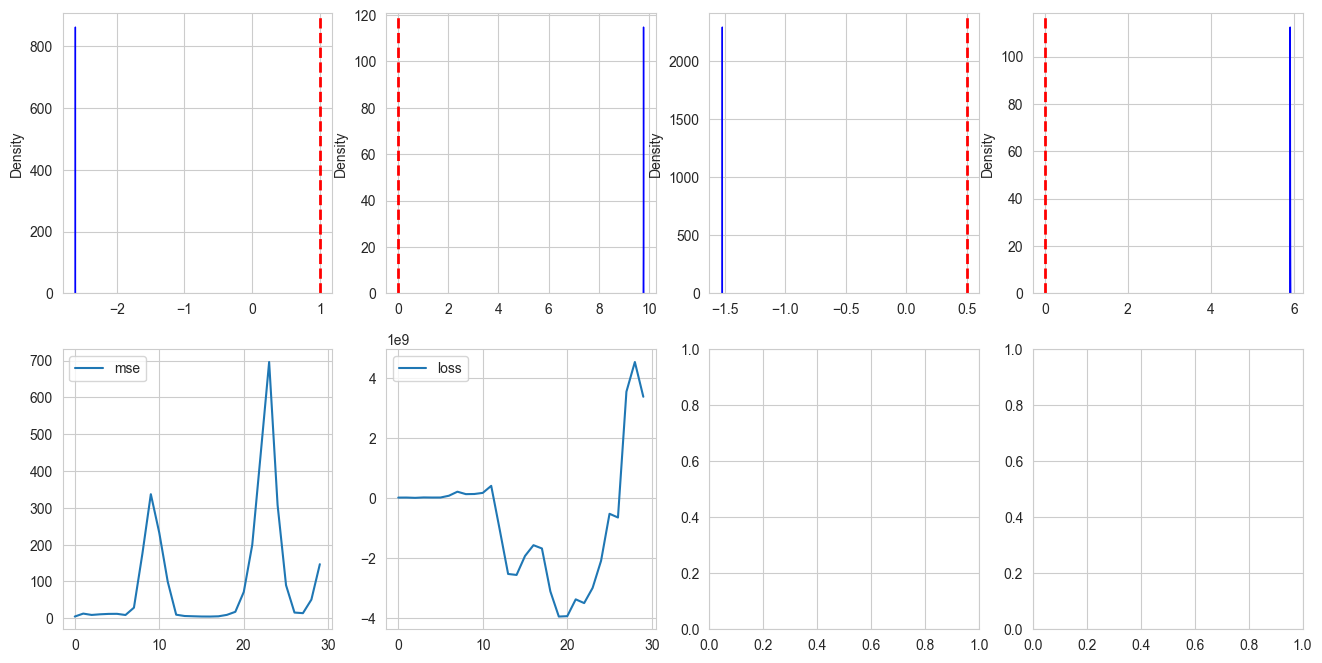

Epoch 6


/Users/kjungeum/PycharmProjects/BGAN/BGAN/_data/lotka_voltera.py:47: RuntimeWarning: overflow encountered in multiply
  xd = x_prev  * (a - b*y_prev)
/Users/kjungeum/PycharmProjects/BGAN/BGAN/_data/lotka_voltera.py:48: RuntimeWarning: overflow encountered in multiply
  yd = -y_prev * (c - d*x_prev)


Epoch 7
Epoch 8
Epoch 9
Epoch 10


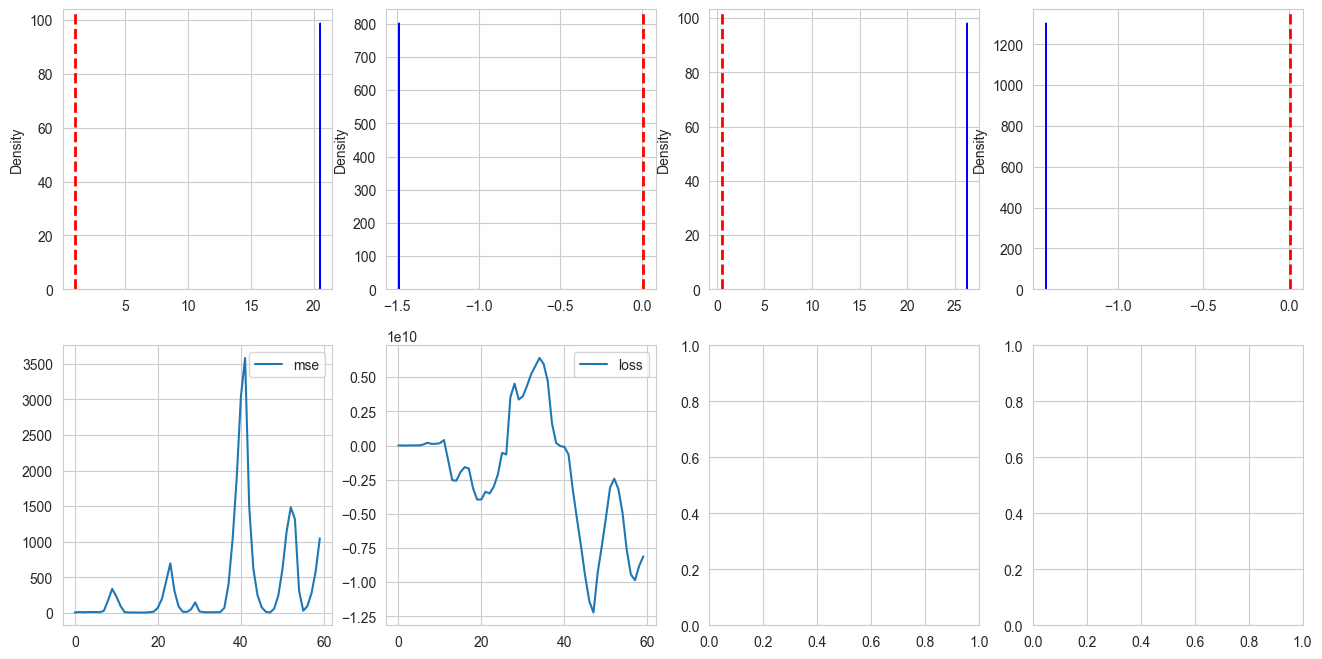

Epoch 11


/Users/kjungeum/PycharmProjects/BGAN/BGAN/_data/lotka_voltera.py:47: RuntimeWarning: overflow encountered in multiply
  xd = x_prev  * (a - b*y_prev)
/Users/kjungeum/PycharmProjects/BGAN/BGAN/_data/lotka_voltera.py:48: RuntimeWarning: overflow encountered in multiply
  yd = -y_prev * (c - d*x_prev)


Epoch 12
Epoch 13


KeyboardInterrupt: 

In [36]:
for j in range(5):
    method.train(true_x=X0_rep, true_thetas=true_thetas,
                 msr = "mse",
                 start_epoch=5*j+1, end_epoch=5*(j+1), n_iter=100)
    plot(method)
    #plot(method)
    #print(method.qualities[-1])